In [1]:
# importing the libraries: 

import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

print("Done")

Done


In [9]:
# setting training and testing directories: 
train_dir = r"/mnt/d/VS Code Projects/Udemy/NLP/chest_xray/train"
test_dir = r"/mnt/d/VS Code Projects/Udemy/NLP/chest_xray/test"

# defining the categories:
categories = ['NORMAL','PNEUMONIA']
img_size = 100

In [7]:
# loading the data function: 
def load_data(dir):
    data = []
    for category in categories: 
        path = os.path.join(train_dir, category)
        class_num = categories.index(category)
        for img in os.listdir(path):

            #reading every image in the directory:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)

            # resizing every image to 100*100:
            new_array = cv2.resize(img_array, (img_size, img_size))

            # making the dataset:
            data.append([new_array, class_num])

    return data

In [10]:
print("loading training data: ")
training_data = load_data(train_dir)
print("done")

loading training data: 
done


In [11]:
# separating the features and labels, i.e., image and category:

X_train = []
y_train = []

for feature, label in training_data:
    X_train.append(feature)
    y_train.append(label)


In [14]:
# converting to numpy arrays:
X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape X: (-1 means "however many images we have", img_size, img_size, 1 means "1 color channel/grayscale")
X_train = X_train.reshape(-1, img_size, img_size, 1)

In [15]:
# Normalize the data: Pixel values are 0-255. Neural networks learn much better when values are between 0 and 1.
X_train = X_train / 255.0

In [17]:
X_train.shape

(5226, 100, 100, 1)

# Defining the model:

In [22]:
model = Sequential()

# Layer 1 of Convolution Model:
model.add(Conv2D(64, (3,3), input_shape=X_train.shape[1:]))
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))


# Layer 2 of Convolution Model:
model.add(Conv2D(128, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Layer 3 of Model:
model.add(Conv2D(256, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Layer 4 of model:
model.add(Conv2D(512, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# adding the flattening layer: 
model.add(Flatten())

# adding the dense layer:
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.3))


# Output layer: 
model.add(Dense(1))
model.add(Activation('sigmoid'))

print(model.summary())



/home/varun/tf-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,074,241 (7.91 MB)

 Trainable params: 2,074,241 (7.91 MB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
# training model on gpu: 
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

with tf.device('/GPU:0'):
    model.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    print("Starting training on GPU.....")

    # actual training step:
    history = model.fit(X_train, y_train, batch_size=32, epochs=64)

    print("Training Done.....")

Num GPUs Available:  1
Starting training on GPU.....
Epoch 1/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7941 - loss: 0.4424
Epoch 2/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9265 - loss: 0.1902
Epoch 3/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9445 - loss: 0.1529
Epoch 4/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9568 - loss: 0.1186
Epoch 5/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9688 - loss: 0.0937
Epoch 6/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9701 - loss: 0.0875
Epoch 7/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9736 - loss: 0.0760
Epoch 8/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9763 - loss: 0.0694
Epoch 9/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9761 - loss: 0.0674
Epoch 10/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9837 - loss: 0.0533
Epoch 11/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9830 - l

In [24]:
# loading the testing data: 
testing_data = load_data(test_dir)

X_test = []
y_test = []

for feature, label in testing_data:
    X_test.append(feature)
    y_test.append(label)


X_test = np.array(X_test)
X_test = X_test/255
y_test = np.array(y_test)

X_test = X_test.reshape(-1, img_size, img_size, 1)


# Evaluating the model's performance on testing data:

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Testing Accuracy is: ", test_acc)

164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9994 - loss: 0.0016    
Testing Accuracy is:  0.9994259476661682



Analyzing image: NORMAL2-IM-1436-0001.jpeg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Prediction: NORMAL
Confidence: 99.98%


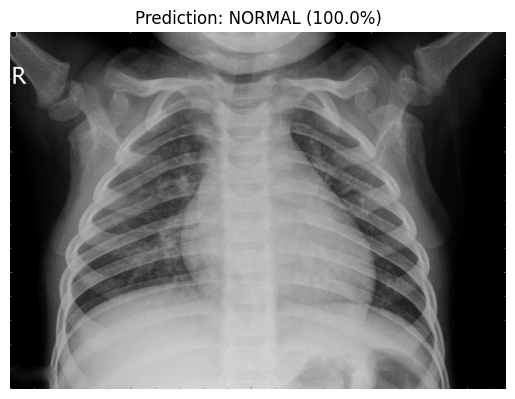


Analyzing image: person1952_bacteria_4883.jpeg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction: PNEUMONIA
Confidence: 100.00%


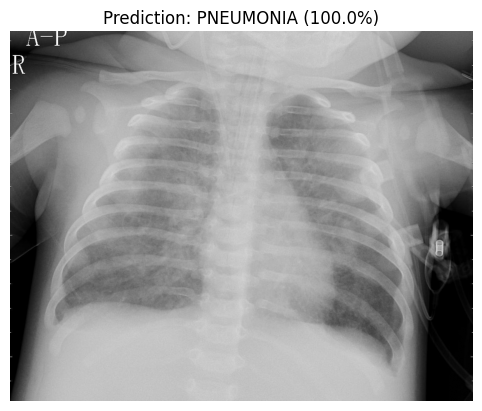

In [ ]:
import matplotlib.pyplot as plt
# 7. Predict on a single new image

def predict_single_image(image_path):
    # 1. Read the image in grayscale
    img_array = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Safety check in case the file path is wrong
    if img_array is None:
        print(f"Error: Could not read image at {image_path}. Check the file path.")
        return

    # 2. Resize to match the input shape of the model (100x100)
    new_array = cv2.resize(img_array, (img_size, img_size))

    # 3. Reshape for the model: (batch_size, height, width, channels)
    # The '1' at the beginning means we are feeding the model a batch containing exactly 1 image.
    reshaped_array = new_array.reshape(1, img_size, img_size, 1)

    # 4. Normalize the data (divide by 255 just like in training)
    normalized_array = reshaped_array / 255.0

    # 5. Make the prediction
    print(f"\nAnalyzing image: {os.path.basename(image_path)}...")
    prediction = model.predict(normalized_array)
    
    # 6. Interpret the result
    # Because we used a 'sigmoid' activation in the final Dense layer, 
    # the output is a single probability float between 0.0 and 1.0.
    probability = prediction[0][0]
    
    # In our CATEGORIES list: index 0 is NORMAL, index 1 is PNEUMONIA
    if probability >= 0.5:
        predicted_class = "PNEUMONIA"
        confidence = probability * 100
    else:
        predicted_class = "NORMAL"
        # If it's Normal (closer to 0), the confidence is the inverse
        confidence = (1 - probability) * 100 

    # Print the text result to the terminal
    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    # 7. Display the image with the result as the title
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Prediction: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off') # Hide the axis numbers
    plt.show()

# Example 1: Testing a Normal Image
normal_image_path = r"/mnt/d/VS Code Projects/Udemy/NLP/chest_xray/val/NORMAL/NORMAL2-IM-1436-0001.jpeg" 
predict_single_image(normal_image_path)

# Example 2: Testing a Pneumonia Image
pneumonia_image_path = r"/mnt/d/VS Code Projects/Udemy/NLP/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg"
predict_single_image(pneumonia_image_path)